<a href="https://colab.research.google.com/github/gracella12/CVL_Assignment/blob/main/CVL_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Computer Vision Assignment 1**

Nama: Gracella Wiendy Koesnadi

NIM: 24/541739/PA/22991



---


**Instruction**

Perform an implementation for image enhancement in any image types (blurred image, dark image, bright image, low-contrast image, etc).

In [5]:
#import libraries
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image

#Low Contrast Image

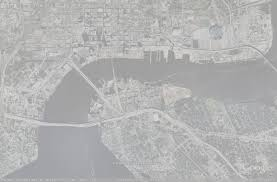

In [6]:
image_path = "/content/lowcontrast4.jpg"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#visualize
image_visual = Image.open(image_path)
image_visual

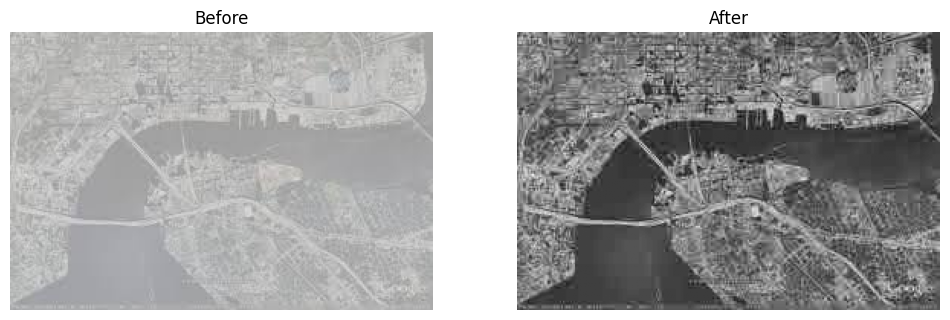

In [7]:
#perform contrast streching
h,w = image.shape[:2]

min_source = float(image.min()) #mengambil intensitas minimal
max_source = float(image.max())#mengambil intensitas maximal

a, b = 0, 255
final = np.zeros((h,w), dtype=np.uint8)
for i in range (0,h):
  for j in range (0,w):
    pin = float(image[i,j])
    pout = (pin - min_source) * ((b - a) / (max_source - min_source)) + a
    final[i,j] = np.clip(pout, a, b)

#visualization
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Before")
plt.imshow(image_visual, cmap='gray')
plt.axis('off') # Menghilangkan angka koordinat di pinggir

plt.subplot(1, 2, 2)
plt.title("After")
plt.imshow(final, cmap='gray')
plt.axis('off')

plt.show()

In [8]:
print(min_source)
print(max_source)

143.0
228.0


Dapat dilihat bahwa sebelumnya gambarnya memiliki masalah low contrast dimana selisih antara intensitas tinggi dan rendahnya hanya 85. Dengan menggunakan contrast streching untuk masalah tersebut, nilai rentang intensitas yang tadinya sempit menjadi lebih lebar sehingga membuat gambar menjadi lebih jelas. Dapat dilihat bahwa pada gambar sebelah kanan jauh lebih jelas dibandingkan gambar sebelah kiri.

#Blur Image

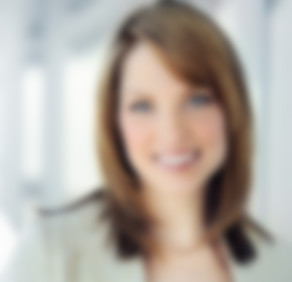

In [9]:
image_path = "/content/blurimage.jpg"
image_blur = cv2.imread(image_path)
image_blur = cv2.cvtColor(image_blur, cv2.COLOR_BGR2GRAY)

#visualize
image_blur_visual = Image.open(image_path)
image_blur_visual

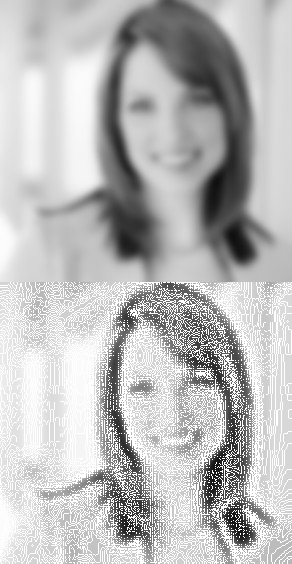

In [10]:
#perform sharpening using laplace filter
h,w = image_blur.shape[:2]
final = np.zeros((h,w), dtype=np.uint16)
pad = 1
padded_img = np.pad(image_blur, pad, mode='edge')

kernel_laplacian = np.array([[  0,  1,  0],
                             [  1, -4,  1],
                             [  0,  1,  0]])

for i in range(h):
    for j in range(w):
        region = padded_img[i:i+3, j:j+3]
        pixel_value = np.sum(region * kernel_laplacian)
        final[i, j] = pixel_value

sharpened = image_blur.astype(np.int32) + final
sharpened_final = np.clip(sharpened, 0, 255).astype(np.uint8)

#visualization
combined = np.vstack((image_blur, sharpened_final))
display(Image.fromarray(combined))

Pada masalah citra yang blur, akan dilakukan sharpening dimana meningkatkan ketajaman sebuah citra agar citra terlihat lebih jelas seperti linenya. Pada sharpening ini, digunakan laplacian kernel, dimana hasilnya adalah outline dari citra kemudian digabungkan dengan citra aslinya. Dapat dilihat bahwa gambar dibahwa terlihat lebih jelas linenya mana yang menjadi wajahnya, rambutnya dibandingkan gambar yang diatas.

#Bright Image

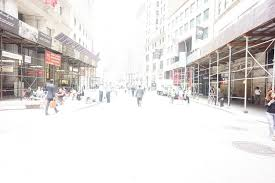

In [11]:
image_path = "/content/brightimage.jpg"
image_bright = cv2.imread(image_path)
image_bright = cv2.cvtColor(image_bright, cv2.COLOR_BGR2GRAY)

#visualize
image_bright_visual = Image.open(image_path)
image_bright_visual

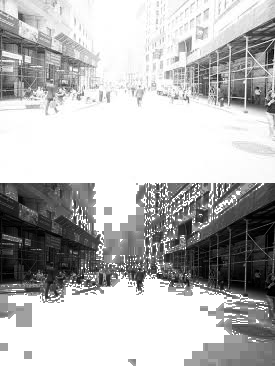

In [12]:
#perform histogram equalization

h,w = image_bright.shape[:2]
final = np.zeros((h,w), dtype=np.uint8)

#hitung frekuensi pixel
hist, bins = np.histogram(image_bright.flatten(), 256, [0,256])

#hitung probabilitas
prob = hist / (h*w)

#hitung kumulatif probabilitas
cdf = np.cumsum(prob)

#scalling
cdf_min = cdf[cdf > 0].min()
cdf_normalized = (cdf - cdf_min) / (1 - cdf_min)
cdf_final = np.floor(255 * cdf_normalized).astype(np.uint8)

for i in range(h):
    for j in range(w):
        pixel_lama = image_bright[i, j]
        pixel_baru = cdf_final[pixel_lama]
        final[i, j] = pixel_baru

#visualization
combined = np.vstack((image_bright, final))
display(Image.fromarray(combined))

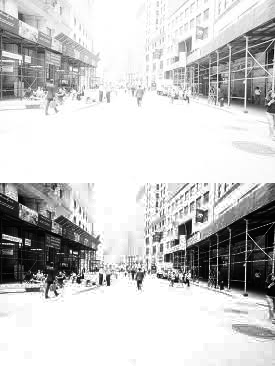

In [13]:
#perform eksponensial transform
h,w = image_bright.shape[:2]
a,b = 0,255
final = np.zeros((h,w), dtype=np.uint8)

#define variable
y = 1.02
c = 255 / (np.power(y, 255) - 1)

for i in range (0,h):
  for j in range (0,w):
    pin = float(image_bright[i,j])
    pout = c * (np.power(y, pin) - 1)
    final[i][j] = np.clip(pout, a, b)

#visualization
combined = np.vstack((image_bright, final))
display(Image.fromarray(combined))


Pada masalah citra yang terlalu terang (overecposure) dapat dilakukan 2 metode, yaitu histogram equalization atau exponential transform (kebalikan dari log transform).

Dalam percobaan ini, dapat dilihat bahwa kedua metode tersebut memang dapat membuat gambar menjadi lebih jelas. Namun, pada histogram equalization, tidak begitu halus hasilnya, sedangkan hasil exponential transform terlihat lebih jelas dan halus. Hal tersebut dikarenakan HE mengubah kontras secara global tanpa mempertimbangkan struktur gambar.

#Dark Image

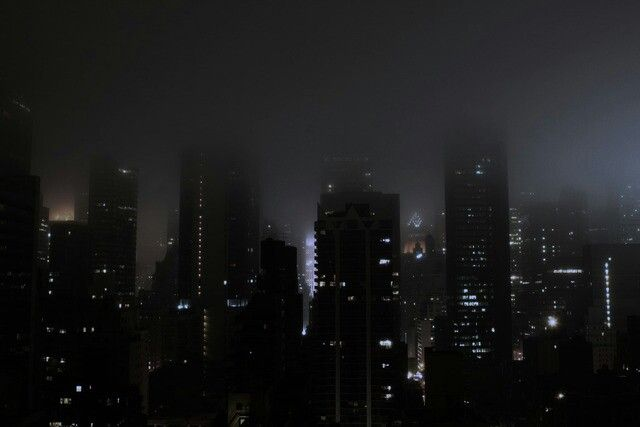

In [14]:
image_path = "/content/darkimage3.jpg"
image_dark = cv2.imread(image_path)
image_dark = cv2.cvtColor(image_dark, cv2.COLOR_BGR2GRAY)

#visualize
image_dark_visual = Image.open(image_path)
image_dark_visual

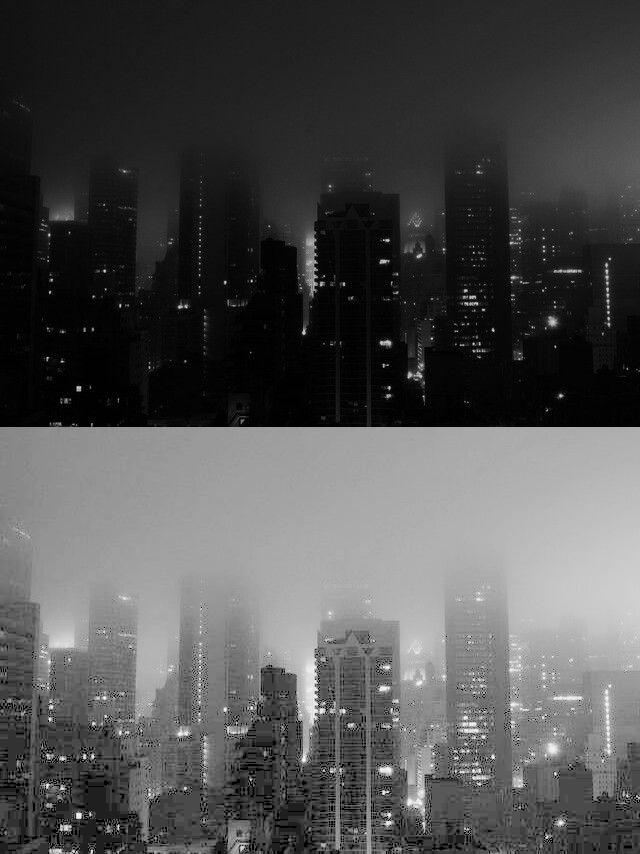

In [15]:
#perform log transfrom

h,w = image_dark.shape[:2]
a,b = 0,255
final = np.zeros((h,w), dtype=np.uint8)

#find maximum c
max_pixel_value = float(np.max(image_dark))
c = 255 // np.log(1 + max_pixel_value)

for i in range (0,h):
  for j in range (0,w):
    pin = float(image_dark[i,j])
    pout = c * np.log(1 + pin)
    final[i][j] = np.clip(pout, a, b)

#visualization
combined = np.vstack((image_dark, final))
display(Image.fromarray(combined))

Pada masalah citra yang terlalu gelap ini, dilakukan log transform dimana yang terang tidak diproses sedangkan yang gelap akan menjadi lebih terang. Pada percobaan diatas, dapat dilihat bahwa pada gambar atas hanya terlihat lampu sedangkan setelah dilakukan log transform, bangunannya juga ikut terlihat.

#Noisy Image

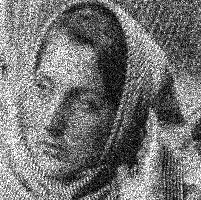

In [16]:
image_path = "/content/noisy.png"
image_noise = cv2.imread(image_path)
image_noise = cv2.cvtColor(image_noise, cv2.COLOR_BGR2GRAY)

#visualize
image_noise_visual = Image.open(image_path)
image_noise_visual

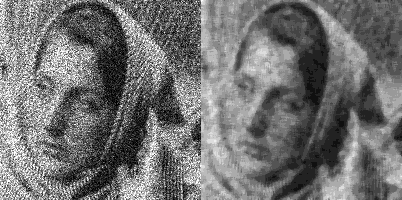

In [17]:
#perform median filter

h,w = image_noise.shape[:2]

def create_kernel(size, sigma):
    ax = np.linspace(-(size - 1) / 2., (size - 1) / 2., size)
    x, y = np.meshgrid(ax, ax)
    exponent = -(x**2 + y**2) / (2 * sigma**2)
    kernel = (1 / (2 * np.pi * sigma**2)) * np.exp(exponent)
    return kernel / np.sum(kernel)

k_size = 5
kernel = create_kernel(k_size, 1.0)
output = np.zeros((h,w), dtype=np.uint8)
pad = k_size//2
padded_img = np.pad(image_noise, pad, mode='edge')

for i in range (0,h):
  for j in range (0,w):
    region = padded_img[i : i + k_size, j : j + k_size]
    median_value = np.median(region)
    output[i, j] = np.clip(median_value, 0, 255)

#visualization
combined = np.hstack((image_noise, output))
display(Image.fromarray(combined))

Pada citra yang banyak noise, akan dilakukan proses smoothing. Pada percobaan ini, digunakan median filter untuk smoothingnya. Hasilnya dapat dilihat pada gambar sebelah kanan dimana sudah tidak se-noise itu tetapi masih diperlukan proses lebih lanjut.

#Uneven Illumination Image


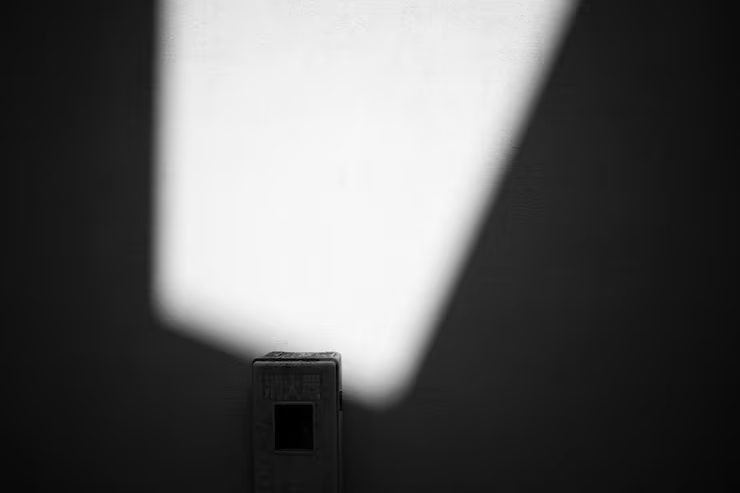

In [18]:
image_path = "/content/unevenimage2.jpg"
image_uneven = cv2.imread(image_path)
image_uneven = cv2.cvtColor(image_uneven, cv2.COLOR_BGR2GRAY)
image_uneven = cv2.resize(image_uneven, (512, 512))

#visualize
image_uneven_visual = Image.open(image_path)
image_uneven_visual.convert('L')

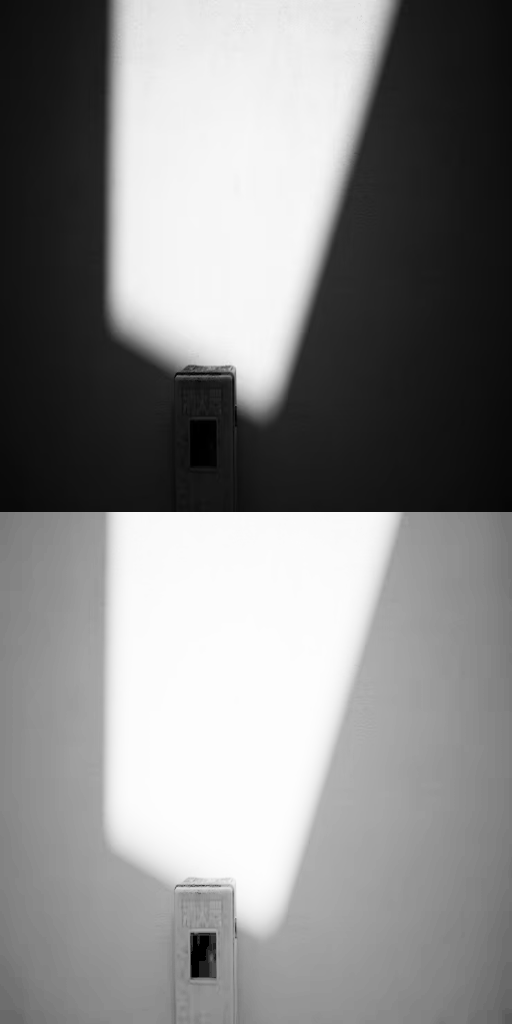

In [19]:
#perform log transfrom

h,w = image_uneven.shape[:2]
a,b = 0,255
final = np.zeros((h,w), dtype=np.uint8)

#find maximum c
max_pixel_value = float(np.max(image_uneven))
c = 255 // np.log(1 + max_pixel_value)

for i in range (0,h):
  for j in range (0,w):
    pin = float(image_uneven[i,j])
    pout = c * np.log(1 + pin)
    final[i][j] = np.clip(pout, a, b)

#visualization
combined = np.vstack((image_uneven, final))
display(Image.fromarray(combined))

Uneven illumination merupakan citra yang memiliki brightness yang tidak merata. Pada gambar diatas, dapat dilihat bahwa terdapat bagian yang sangat gelap, tetapi juga terdapat bagian yang sangat terang. Karena bagian gelapnya lebih mendominan, akan digunakan log transform untuk enhance citra ini.

Hasilnya dapat dilihat pada gambar di bawah, dimana yang tadinya objek tidak terlihat karena gelap menjadi terlihat. Bagian gelap citra menjadi lebih terang dan bagian terangnya tetap sama (tidak terjadi apa-apa).